In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import (
    f1_score, precision_score, recall_score,
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)
from skimage.feature import hog
from linear_svm import LinearSVMScartch

RANDOM_STATE = 42

In [2]:
print('Loading MNIST...')
mnist = fetch_openml('mnist_784', version=1, as_frame=False,
                     parser='auto', data_home='d:/sklearn_data')
X_all, y_digits = mnist.data, mnist.target.astype(int)

# Binary labels: +1 if digit is 6, -1 otherwise
y_all = np.where(y_digits == 6, 1, -1)

# Normalize pixels to [0, 1]
X_all = X_all / 255.0

# Split 60/20/20 stratified
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X_all, y_all, test_size=0.20, stratify=y_all, random_state=RANDOM_STATE)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.25, stratify=y_trainval, random_state=RANDOM_STATE)

print(f'Train : {len(y_train)}')
print(f'Val   : {len(y_val)}')
print(f'Test  : {len(y_test)}')
print(f'Class +1 (is 6): {(y_train==1).sum()}  ({(y_train==1).mean()*100:.1f}%)')
print(f'Class -1 (not 6): {(y_train==-1).sum()}  ({(y_train==-1).mean()*100:.1f}%)')

Loading MNIST...
Train : 42000
Val   : 14000
Test  : 14000
Class +1 (is 6): 4126  (9.8%)
Class -1 (not 6): 37874  (90.2%)


In [3]:
# HOG extraction matching Binary.ipynb settings exactly
def extract_hog(X):
    features = []
    for img in X:
        h = hog(
            img.reshape(28, 28),
            orientations=9,
            pixels_per_cell=(4, 4),
            cells_per_block=(2, 2),
            block_norm='L2-Hys',
            feature_vector=True
        )
        features.append(h)
    return np.array(features)

In [4]:
def build_pipelines(X_tr, X_v, X_te):
    pipelines = {}

    # Pipeline 1: Raw Pixels — flatten + StandardScaler
    print('Pipeline 1: Raw Pixels...')
    scaler1 = StandardScaler()
    pipelines['Raw Pixels'] = (
        scaler1.fit_transform(X_tr),
        scaler1.transform(X_v),
        scaler1.transform(X_te)
    )

    # Pipeline 2: PCA only — StandardScaler then PCA(50)
    print('Pipeline 2: PCA only...')
    scaler2 = StandardScaler()
    X_tr2_s = scaler2.fit_transform(X_tr)
    X_v2_s  = scaler2.transform(X_v)
    X_te2_s = scaler2.transform(X_te)
    pca2 = PCA(n_components=50, random_state=RANDOM_STATE)
    pipelines['PCA only'] = (
        pca2.fit_transform(X_tr2_s),
        pca2.transform(X_v2_s),
        pca2.transform(X_te2_s)
    )

    # Pipeline 3: HOG only — HOG + StandardScaler
    print('Pipeline 3: HOG only — extracting features (train)...')
    X_tr_hog = extract_hog(X_tr)
    print('Pipeline 3: HOG only — extracting features (val)...')
    X_v_hog  = extract_hog(X_v)
    print('Pipeline 3: HOG only — extracting features (test)...')
    X_te_hog = extract_hog(X_te)
    scaler3 = StandardScaler()
    X_tr3 = scaler3.fit_transform(X_tr_hog)
    X_v3  = scaler3.transform(X_v_hog)
    X_te3 = scaler3.transform(X_te_hog)
    pipelines['HOG only'] = (X_tr3, X_v3, X_te3)

    # Pipeline 4: HOG + PCA — same as Binary.ipynb
    # HOG already extracted above, apply PCA on top
    print('Pipeline 4: HOG + PCA...')
    pca4 = PCA(n_components=50, random_state=RANDOM_STATE)
    pipelines['HOG + PCA'] = (
        pca4.fit_transform(X_tr3),
        pca4.transform(X_v3),
        pca4.transform(X_te3)
    )

    print('All pipelines ready.')
    return pipelines

pipelines = build_pipelines(X_train, X_val, X_test)

Pipeline 1: Raw Pixels...
Pipeline 2: PCA only...
Pipeline 3: HOG only — extracting features (train)...
Pipeline 3: HOG only — extracting features (val)...
Pipeline 3: HOG only — extracting features (test)...
Pipeline 4: HOG + PCA...
All pipelines ready.


In [5]:
def grid_search(X_tr, y_tr, X_v, y_v, pipeline_name):
    C_values  = [0.01, 0.1, 1.0, 10.0]
    lr_values = [0.001, 0.0005, 0.0001]

    print(f'\n{"="*55}')
    print(f'Grid Search: {pipeline_name}')
    print(f'{"="*55}')
    print(f'{"C":>8}  {"LR":>8}  {"Val F1":>10}')
    print('-' * 32)

    results = []
    for C in C_values:
        for lr in lr_values:
            clf = LinearSVMScartch(
                C=C, learning_rate=lr, n_epochs=30,
                batch_size=64, use_class_weights=True,
                random_state=RANDOM_STATE
            )
            clf.fit(X_tr, y_tr)
            f1 = f1_score(y_v, clf.predict(X_v))
            results.append((C, lr, f1))
            print(f'{C:>8}  {lr:>8}  {f1:>10.4f}')

    best = max(results, key=lambda x: x[2])
    print(f'\nBest: C={best[0]}, lr={best[1]}, Val F1={best[2]:.4f}')
    return best[0], best[1]

In [6]:
def evaluate_pipeline(name, X_tr, y_tr, X_te, y_te, best_C, best_lr, save_path):
    print(f'\nTraining final model for: {name}...')
    clf = LinearSVMScartch(
        C=best_C, learning_rate=best_lr, n_epochs=50,
        batch_size=64, use_class_weights=True,
        random_state=RANDOM_STATE
    )
    clf.fit(X_tr, y_tr)
    y_pred = clf.predict(X_te)

    prec = precision_score(y_te, y_pred)
    rec  = recall_score(y_te, y_pred)
    f1   = f1_score(y_te, y_pred)
    acc  = accuracy_score(y_te, y_pred)

    print(f'\n--- {name} ---')
    print(f'Best params: C={best_C}, lr={best_lr}')
    print('Classification Report:')
    print(classification_report(y_te, y_pred, target_names=['Not 6', 'Is 6']))
    print(f'Overall Accuracy: {acc:.4f}')

    # Confusion matrix saved to SVM folder
    cm = confusion_matrix(y_te, y_pred, labels=[-1, 1])
    disp = ConfusionMatrixDisplay(cm, display_labels=['Not 6', 'Is 6'])
    fig, ax = plt.subplots(figsize=(5, 5))
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f'Confusion Matrix — {name}')
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {save_path}')

    return prec, rec, f1, acc


Grid Search: Raw Pixels
       C        LR      Val F1
--------------------------------
    0.01     0.001      0.8577
    0.01    0.0005      0.8450
    0.01    0.0001      0.6794
     0.1     0.001      0.8817
     0.1    0.0005      0.8787
     0.1    0.0001      0.8584
     1.0     0.001      0.8594
     1.0    0.0005      0.8611
     1.0    0.0001      0.8804
    10.0     0.001      0.8490
    10.0    0.0005      0.8614
    10.0    0.0001      0.8683

Best: C=0.1, lr=0.001, Val F1=0.8817

Training final model for: Raw Pixels...

--- Raw Pixels ---
Best params: C=0.1, lr=0.001
Classification Report:
              precision    recall  f1-score   support

       Not 6       1.00      0.97      0.98     12625
        Is 6       0.79      0.98      0.88      1375

    accuracy                           0.97     14000
   macro avg       0.90      0.97      0.93     14000
weighted avg       0.98      0.97      0.97     14000

Overall Accuracy: 0.9728


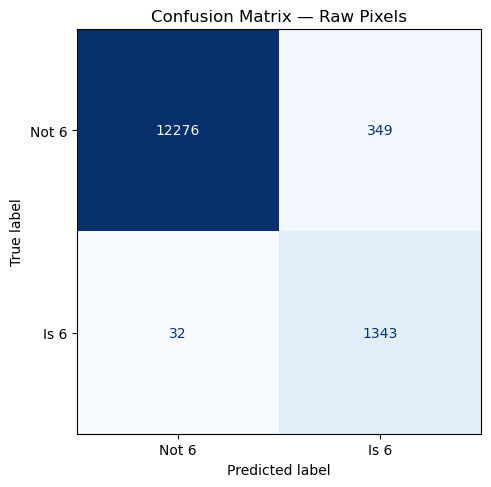

Saved: confusion_raw.png

Grid Search: PCA only
       C        LR      Val F1
--------------------------------
    0.01     0.001      0.8508
    0.01    0.0005      0.8381
    0.01    0.0001      0.6670
     0.1     0.001      0.8624
     0.1    0.0005      0.8641
     0.1    0.0001      0.8496
     1.0     0.001      0.8776
     1.0    0.0005      0.8624
     1.0    0.0001      0.8619
    10.0     0.001      0.7637
    10.0    0.0005      0.8261
    10.0    0.0001      0.8637

Best: C=1.0, lr=0.001, Val F1=0.8776

Training final model for: PCA only...

--- PCA only ---
Best params: C=1.0, lr=0.001
Classification Report:
              precision    recall  f1-score   support

       Not 6       1.00      0.97      0.98     12625
        Is 6       0.75      0.97      0.85      1375

    accuracy                           0.97     14000
   macro avg       0.88      0.97      0.92     14000
weighted avg       0.97      0.97      0.97     14000

Overall Accuracy: 0.9661


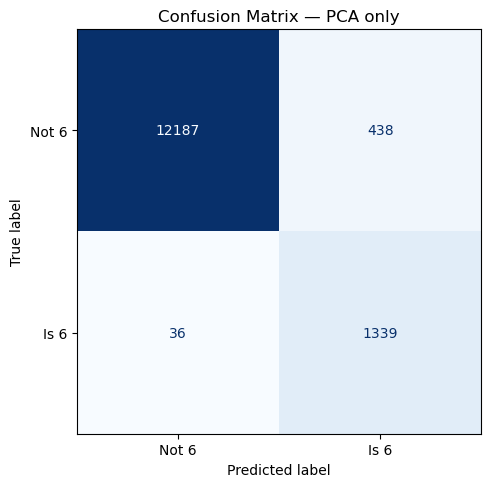

Saved: confusion_pca.png

Grid Search: HOG only
       C        LR      Val F1
--------------------------------
    0.01     0.001      0.9651
    0.01    0.0005      0.9582
    0.01    0.0001      0.8262
     0.1     0.001      0.9673
     0.1    0.0005      0.9649
     0.1    0.0001      0.9591
     1.0     0.001      0.9520
     1.0    0.0005      0.9595
     1.0    0.0001      0.9662
    10.0     0.001      0.9331
    10.0    0.0005      0.9532
    10.0    0.0001      0.9565

Best: C=0.1, lr=0.001, Val F1=0.9673

Training final model for: HOG only...

--- HOG only ---
Best params: C=0.1, lr=0.001
Classification Report:
              precision    recall  f1-score   support

       Not 6       1.00      0.99      1.00     12625
        Is 6       0.94      0.99      0.96      1375

    accuracy                           0.99     14000
   macro avg       0.97      0.99      0.98     14000
weighted avg       0.99      0.99      0.99     14000

Overall Accuracy: 0.9926


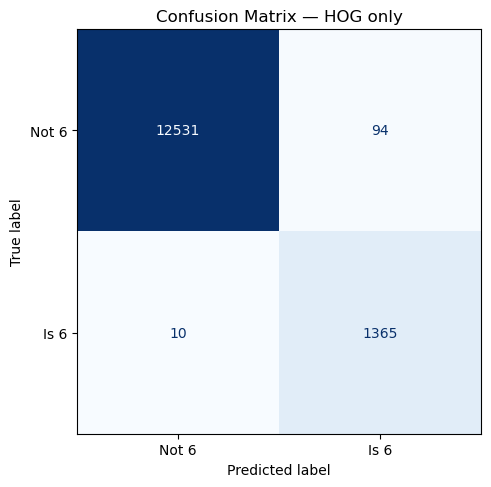

Saved: confusion_hog.png

Grid Search: HOG + PCA
       C        LR      Val F1
--------------------------------
    0.01     0.001      0.9501
    0.01    0.0005      0.9432
    0.01    0.0001      0.7955
     0.1     0.001      0.9440
     0.1    0.0005      0.9478
     0.1    0.0001      0.9396
     1.0     0.001      0.9535
     1.0    0.0005      0.9532
     1.0    0.0001      0.9447
    10.0     0.001      0.9279
    10.0    0.0005      0.9319
    10.0    0.0001      0.9434

Best: C=1.0, lr=0.001, Val F1=0.9535

Training final model for: HOG + PCA...

--- HOG + PCA ---
Best params: C=1.0, lr=0.001
Classification Report:
              precision    recall  f1-score   support

       Not 6       1.00      0.99      0.99     12625
        Is 6       0.88      0.99      0.93      1375

    accuracy                           0.99     14000
   macro avg       0.94      0.99      0.96     14000
weighted avg       0.99      0.99      0.99     14000

Overall Accuracy: 0.9857


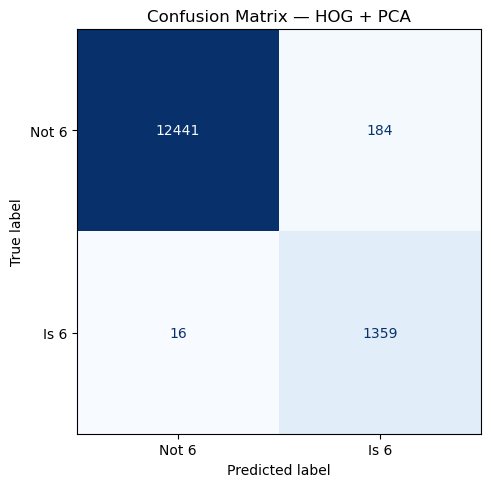

Saved: confusion_hog_pca.png


In [7]:
pipeline_configs = [
    ('Raw Pixels', 'confusion_raw.png'),
    ('PCA only',   'confusion_pca.png'),
    ('HOG only',   'confusion_hog.png'),
    ('HOG + PCA',  'confusion_hog_pca.png'),
]

summary = []

for name, confusion_file in pipeline_configs:
    X_tr, X_v, X_te = pipelines[name]
    best_C, best_lr = grid_search(X_tr, y_train, X_v, y_val, name)
    prec, rec, f1, acc = evaluate_pipeline(
        name, X_tr, y_train, X_te, y_test,
        best_C, best_lr, confusion_file
    )
    summary.append((name, best_C, best_lr, prec, rec, f1, acc))

In [8]:
print('\n' + '='*90)
print('SUMMARY TABLE')
print('='*90)
print(f'{"Feature Config":<15} | {"Best C":>6} | {"Best LR":>8} | {"Precision(6)":>12} | {"Recall(6)":>9} | {"F1(6)":>6} | {"Accuracy":>8}')
print('-'*90)
for name, C, lr, prec, rec, f1, acc in summary:
    print(f'{name:<15} | {C:>6} | {lr:>8} | {prec:>12.4f} | {rec:>9.4f} | {f1:>6.4f} | {acc:>8.4f}')
print('='*90)


SUMMARY TABLE
Feature Config  | Best C |  Best LR | Precision(6) | Recall(6) |  F1(6) | Accuracy
------------------------------------------------------------------------------------------
Raw Pixels      |    0.1 |    0.001 |       0.7937 |    0.9767 | 0.8758 |   0.9728
PCA only        |    1.0 |    0.001 |       0.7535 |    0.9738 | 0.8496 |   0.9661
HOG only        |    0.1 |    0.001 |       0.9356 |    0.9927 | 0.9633 |   0.9926
HOG + PCA       |    1.0 |    0.001 |       0.8808 |    0.9884 | 0.9315 |   0.9857


In [10]:

# Confusion matrix numbers for HOG only
X_tr, X_v, X_te = pipelines['HOG only']

# find best params from summary
hog_entry = next(s for s in summary if s[0] == 'HOG only')
best_C, best_lr = hog_entry[1], hog_entry[2]

clf = LinearSVMScartch(C=best_C, learning_rate=best_lr, n_epochs=50,
                        batch_size=64, use_class_weights=True, random_state=RANDOM_STATE)
clf.fit(X_tr, y_train)
y_pred_hog = clf.predict(X_te)

cm = confusion_matrix(y_test, y_pred_hog, labels=[-1, 1])

print('=== HOG Only — Confusion Matrix ===')
print(f'                  Predicted Not 6   Predicted Is 6')
print(f'Actual Not 6      {cm[0,0]:>14}   {cm[0,1]:>14}')
print(f'Actual Is 6       {cm[1,0]:>14}   {cm[1,1]:>14}')
print()
print(f'True Negatives  (TN): {cm[0,0]}  — correctly predicted Not 6')
print(f'False Positives (FP): {cm[0,1]}  — wrongly predicted as 6')
print(f'False Negatives (FN): {cm[1,0]}  — missed real 6s')
print(f'True Positives  (TP): {cm[1,1]}  — correctly predicted Is 6')


=== HOG Only — Confusion Matrix ===
                  Predicted Not 6   Predicted Is 6
Actual Not 6               12531               94
Actual Is 6                   10             1365

True Negatives  (TN): 12531  — correctly predicted Not 6
False Positives (FP): 94  — wrongly predicted as 6
False Negatives (FN): 10  — missed real 6s
True Positives  (TP): 1365  — correctly predicted Is 6


In [9]:
for name, best_C, best_lr, prec, rec, f1, acc in summary:
    print(f"{name}: best_val_f1 = ???")

Raw Pixels: best_val_f1 = ???
PCA only: best_val_f1 = ???
HOG only: best_val_f1 = ???
HOG + PCA: best_val_f1 = ???
